In [1]:
import tensorflow as tf
from tensorflow import keras

2026-02-07 13:09:06.842224: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-07 13:09:06.947269: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [31]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

In [35]:
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000] , y_train_full[5000:]
X_test = X_test / 255.

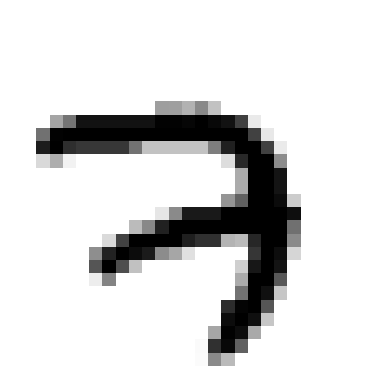

In [33]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap="binary")
plt.axis("off")
plt.show() 

In [36]:
y_train

array([7, 3, 4, ..., 5, 6, 8], shape=(55000,), dtype=uint8)

In [66]:
K = keras.backend

class ExponentialLearningRate(keras.callbacks.Callback):
    def __init__(self, factor):
        self.factor = factor
        self.rates = []
        self.losses = []
    def on_batch_end(self, batch, logs):
        print(logs)
        self.rates.append(K.get_value(self.model.optimizer.learning_rate))
        if "loss" in logs:
            print("Didnt contain loss")
            self.losses.append(logs["loss"])
        K.set_value(self.model.optimizer.learning_rate, self.model.optimizer.learning_rate * self.factor)

In [67]:
keras.backend.clear_session()
import numpy as np
np.random.seed(42)
tf.random.set_seed(42)

In [68]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

In [69]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=["accuracy"])
expon_lr = ExponentialLearningRate(factor=1.005)

In [70]:
history = model.fit(X_train, y_train, epochs=1, validation_data=(X_valid, y_valid),
                    callbacks=[expon_lr])

{'accuracy': 0.15625, 'loss': 2.281190872192383}
Didnt contain loss


AttributeError: 'str' object has no attribute 'name'

In [25]:
X_train, X_test = X_train.reshape(-1, 784), X_test.reshape(-1, 784)

In [26]:
input_ = keras.layers.Input(shape=X_train.shape)
hidden1 = keras.layers.Dense(30, activation="relu")(input_)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
output = keras.layers.Dense(10)(hidden2)
model = keras.Model(inputs=[input_], outputs=[output])
optimizer = keras.optimizers.SGD(learning_rate=learning_rate)

In [27]:
def build_model(n_hidden=2, n_neurons = 2, learning_rate=3e-3, input_shape=[784]):
    input_ = keras.layers.Input(shape=X_train.shape)
    hidden1 = keras.layers.Dense(30, activation="relu")(input_)
    hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
    output = keras.layers.Dense(10)(hidden2)
    model = keras.Model(inputs=[input_], outputs=[output])
    optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    model.compile(loss="accuracy", optimizer=optimizer)
    return model

In [28]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("mnist_model.h5", save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

# history = model.fit(X_train, y_train, epochs=100, validation_split=0.2, callbacks=[checkpoint_cb, early_stopping_cb])


In [29]:
keras_reg = keras.wrappers.scikit_learn.KerasRegressor(build_model)

keras_reg.fit(X_train, y_train, epochs=100, validation_split=0.2, callbacks=[checkpoint_cb, early_stopping_cb])

accuracy_test = keras_reg.score(X_test, y_test)

AttributeError: module 'keras.wrappers' has no attribute 'scikit_learn'